<p>
    <a href="https://umt.edu.al/en/anxhelo-shehu/" target="_blank">
    <img src="https://umt.edu.al/wp-content/uploads/2022/10/Anxhelo-Shehu-min-2-300x300.jpg" width="150" alt="UMT Logo">
    </a>
</p>
<p>
    <a href="https://umt.edu.al/" target="_blank">
    <img src="https://umt.edu.al/wp-content/uploads/2024/11/Universiteti-Metropolitan-Tirana.webp" width="200" alt="UMT Logo">
    </a>
</p>

<h1> Rikuperimi dhe Rindërtimi i Imazhit (Vazhdim ...): </h1>

Koha e nevojshme per kete Lab: **+60** minuta


- **<h2> Degradimi </h2>**
- **<h2> Rikuperimi i imazhit </h2>**

## Rikuperimi i imazhit

Rikuperoni një imazh që është degraduar duke përdorur një njohuri paraprake të fenomenit të degradimit.

- Modelojm procesin e degradimit dhe aplikoni procesin e anasjelltë në mënyrë që të rikuperoni imazhin origjinal.

![My Image](degradimi.png)

Shkarkojme  disa nga imazhet e nevojshme per kete laborator


In [ ]:
import requests

# URLs per imazhet
urls = [
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png",
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/barbara.png",
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/cameraman.jpeg"
]

# Shkarkojme edhe ruajm imazhet duke perdorur URL perkatese
for url in urls:
    response = requests.get(url)
    if response.status_code == 200:
        filename = url.split("/")[-1]
        with open(filename, 'wb') as file:
            file.write(response.content)
        print(f"Downloaded: {filename}")
    else:
        print(f"Failed to download: {url}")

Ne importojme librarit e nevojshme

In [1]:
# Përdoret për të shfaqur imazhet
import matplotlib.pyplot as plt
# Përdoret për të ngarkuar një imazh
from PIL import Image
# Përdoret për të krijuar bërthama për filtrimin
import numpy as np
# Përdoret për të ngarkuar një imazh dhe per te kryer operacione mbi te (aplikimi i kernelit mbi imazh)
import cv2

Ky funksion do të paraqesë dy imazhe krah për krah njeri-tjetrit per krahasim

In [2]:
def plot_image(image_1, image_2,title_1="Orignal",title_2="New Image", gray = "yes or no"):
    if gray == "no":
        plt.figure(figsize=(10,10))
        plt.subplot(1, 2, 1)
        plt.imshow(image_1)
        plt.title(title_1)
        plt.subplot(1, 2, 2)
        plt.imshow(image_2)
        plt.title(title_2)
        plt.show()
    else:
        plt.figure(figsize=(10,10))
        plt.subplot(1, 2, 1)
        plt.imshow(image_1, 'gray')
        plt.title(title_1)
        plt.subplot(1, 2, 2)
        plt.imshow(image_2, 'gray')
        plt.title(title_2)
        plt.show()

In [3]:
# per te krahasuar ndryshimin e histogrames ndertojme edhe kete funksion per krahasimin e tyre

In [4]:

def plot_hist(old_image, new_image,title_old="Orignal", title_new="New Image"):
    intensity_values=np.array([x for x in range(256)])
    plt.subplot(1, 2, 1)
    plt.bar(intensity_values, cv2.calcHist([old_image],[0],None,[256],[0,256])[:,0],width = 5)
    plt.title(title_old)
    plt.xlabel('intensity')
    plt.subplot(1, 2, 2)
    plt.bar(intensity_values, cv2.calcHist([new_image],[0],None,[256],[0,256])[:,0],width = 5)
    plt.title(title_new)
    plt.xlabel('intensity')
    plt.show()

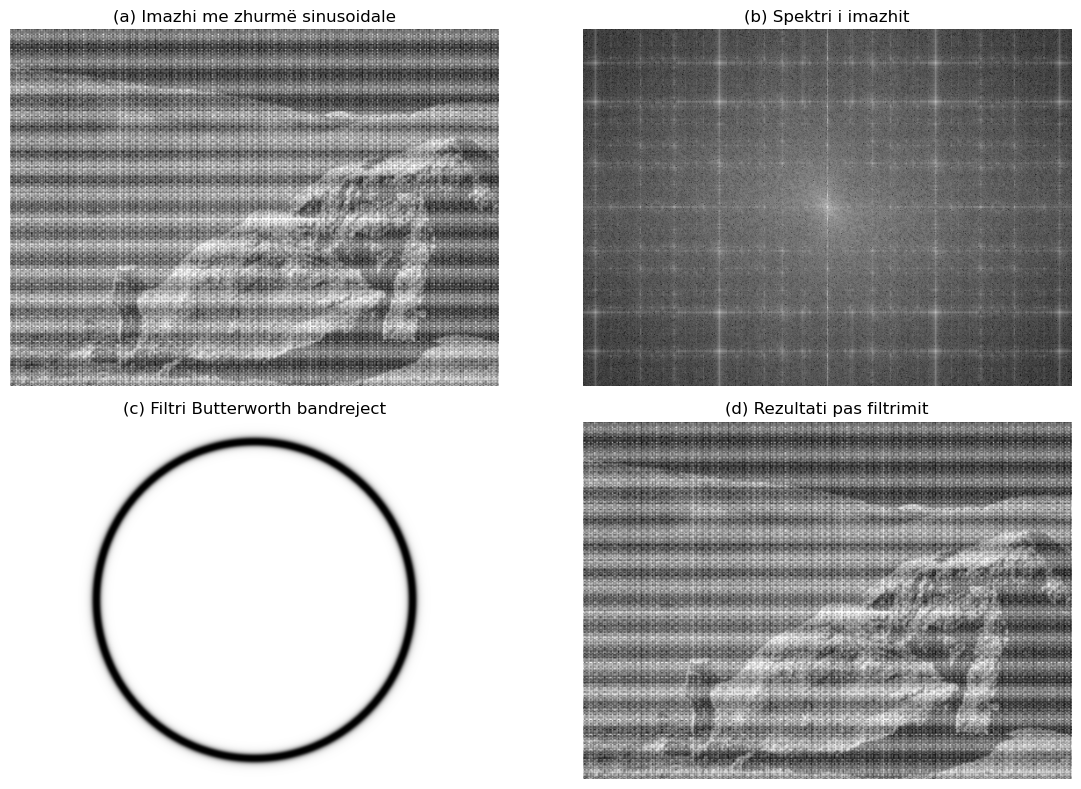

In [6]:

# Leximi i imazhit dhe konvertimi në grayscale
image = cv2.imread('nasa_image.png', cv2.IMREAD_GRAYSCALE)
rows, cols = image.shape

# a) Shtimi i zhurmës sinusoidale
x = np.arange(cols)
y = np.arange(rows)
x, y = np.meshgrid(x, y)
sinusoidal_noise = 30 * np.sin(2 * np.pi * y / 30)
noisy_image = image + sinusoidal_noise
noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)

# b) Spektri i imazhit me zhurmë (transformimi Fourier)
f = np.fft.fft2(noisy_image)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

# c) Filtri Butterworth bandreject
def butterworth_bandreject(shape, D0, W, n):
    P, Q = shape
    H = np.zeros((P, Q), dtype=np.float32)
    u = np.arange(P)
    v = np.arange(Q)
    u, v = np.meshgrid(u - P//2, v - Q//2, indexing='ij')
    D = np.sqrt(u**2 + v**2)
    H = 1 / (1 + ((D*W)/(D**2 - D0**2 + 1e-5))**(2*n))
    return H

D0 = 180    # distanca qendrore
W = 10     # gjerësia e bandes
n = 2      # rregullsia
H = butterworth_bandreject((rows, cols), D0, W, n)

# d) Zbatimi i filtrit dhe rikthimi në hapësirën e imazhit
filtered_fshift = fshift * H
f_ishift = np.fft.ifftshift(filtered_fshift)
img_filtered = np.fft.ifft2(f_ishift)
img_filtered = np.abs(img_filtered)
img_filtered = np.clip(img_filtered, 0, 255).astype(np.uint8)

# Vizualizimi i rezultateve
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(noisy_image, cmap='gray')
plt.title('(a) Imazhi me zhurmë sinusoidale')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('(b) Spektri i imazhit')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(H, cmap='gray')
plt.title('(c) Filtri Butterworth bandreject')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(img_filtered, cmap='gray')
plt.title('(d) Rezultati pas filtrimit')
plt.axis('off')

plt.tight_layout()
plt.show()


### Turbullira atmosferike


Turbullira atmosferike përfaqëson efektet optike të shkaktuara nga ndryshimet në densitetin dhe temperaturën e ajrit në atmosferë. Ato ndikojnë në shpërndarjen dhe përhapjen e dritës, duke shkaktuar turbullim në pamje ose humbje të mprehtësisë së imazheve. Një mënyrë për të modeluar këtë fenomen është përmes funksionit të transferimit të turbullimit në domenin e frekuencës.

---
$$
H(f) = \exp\left[-k \left( f^2 \right)^{5/6} \right]
$$

**Kuptimi i formulës:**

- $ H(f)$: Funksioni i transferimit të turbullimit (në domenin e frekuencës)  
- $ f $: Frekuenca hapësinore  
- $ k $: Koeficienti i turbullimit atmosferik (varion për turbullime të ndryshme)
---

In [7]:

# Funksioni për të aplikuar turbullirë atmosferike në bazë të vlerës k
def apply_atmospheric_turbulence(image, k):
    # Intensiteti i turbullimit përkthehet në standard deviation për Gaussian blur
    sigma = k * 10000  # rregullo sipas nevojës
    kernel_size = int(2 * round(sigma) + 1)
    blurred = cv2.GaussianBlur(image, (kernel_size, kernel_size), sigma)
    return blurred


In [8]:

# Lexo imazhin (sigurohu që të kesh një imazh në të njëjtin direktorium ose ndrysho path-in)
image = cv2.imread('tirana.jpg', cv2.IMREAD_COLOR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Kthehet në RGB për shfaqje me matplotlib
image.shape

(508, 940)

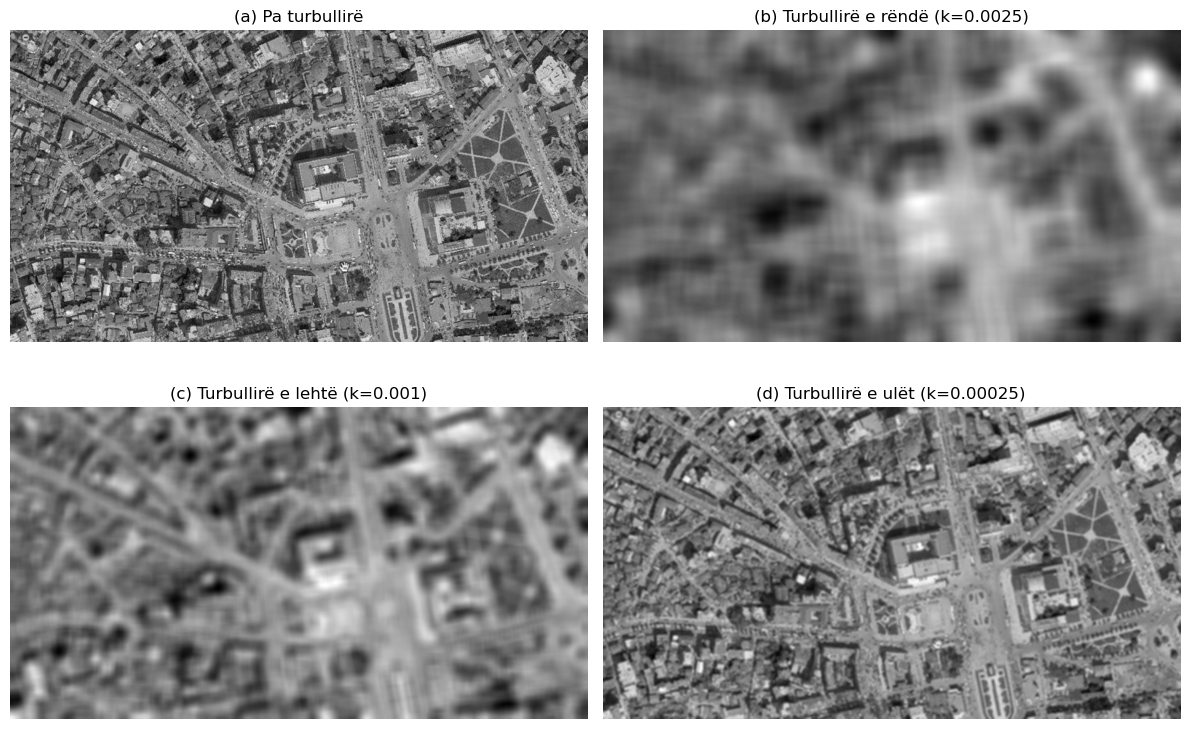

In [10]:
# Krijo versionet me turbullira të ndryshme
turbulence_none = image.copy()
turbulence_heavy = apply_atmospheric_turbulence(image, k=0.0025)
turbulence_medium = apply_atmospheric_turbulence(image, k=0.001)
turbulence_low = apply_atmospheric_turbulence(image, k=0.00025)

# Shfaq rezultatet
titles = ['(a) Pa turbullirë', '(b) Turbullirë e rëndë (k=0.0025)', 
          '(c) Turbullirë e lehtë (k=0.001)', '(d) Turbullirë e ulët (k=0.00025)']
images = [turbulence_none, turbulence_heavy, turbulence_medium, turbulence_low]

plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


### Levizja e njetrajteshme (trajta matematike)

Supozoni që imazhi kalon nëpër një lëvizje lineare të njëtrajtshme në drejtimet $x$- dhe $y$-it, me një shpejtësi të dhënë nga:
$$
x_0 = \frac{a t}{T}, \quad y_0 = \frac{b t}{T}
$$

kjo jepet nga funksioni i degradimit:

$$
H(u,v) = \frac{T}{\pi(ua + vb)} \sin[\pi(ua + vb)] e^{-j\pi(ua + vb)}
$$

In [14]:

# Parametrat e lëvizjes
a = 6
b = 6
T = 1.0


In [12]:

# Funksioni H(u,v) - Funksioni i transferimit i turbullimit nga lëvizja lineare
def motion_blur_filter(u, v, a, b, T):
    pi_term = np.pi * (u * a + v * b)
    # për të shmangur ndarjen me 0
    pi_term[pi_term == 0] = 1e-8
    H = (T / pi_term) * np.sin(pi_term) * np.exp(-1j * pi_term)
    return H

In [16]:

# normalizojme imazhin origjinal
original = cv2.imread('tirana.jpg', cv2.IMREAD_GRAYSCALE)
print(original.shape)
original = original.astype(np.float32) / 255.0  # Normalizim

# Merr përmasat
M, N = original.shape
u = np.linspace(-0.5, 0.5, N)
v = np.linspace(-0.5, 0.5, M)
U, V = np.meshgrid(u, v)

# Llogarit funksionin e transferimit
H_uv = motion_blur_filter(U, V, a, b, T)

# FFT e imazhit
F = np.fft.fftshift(np.fft.fft2(original))

# Apliko turbullimin në domenin e frekuencës
G = F * H_uv

# Rikthehu në domenin hapësinor
blurred = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))



(508, 940)


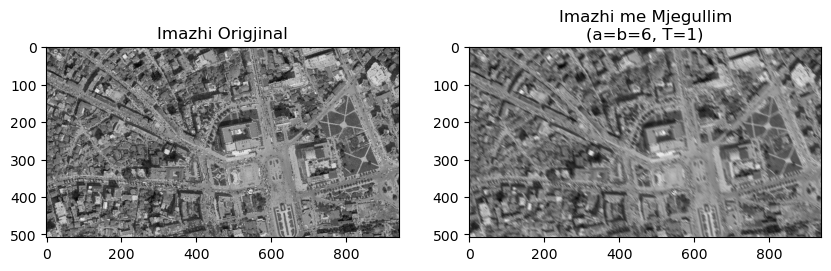

In [17]:
plot_image(original, blurred, title_1="Imazhi Origjinal", title_2="Imazhi me Mjegullim\n(a=b=6, T=1)", gray = "yes")

In [ ]:
original

In [ ]:
blurred

In [18]:
# Shndërrimi në vlera 0-255 dhe konvertimi në uint8
original_ = (original * 255).clip(0, 255).astype(np.uint8)
print(original_)
blurred_ = (blurred * 255).clip(0, 255).astype(np.uint8)

[[169 133 103 ...  88  84  91]
 [145 154 146 ...  92  95 100]
 [159 161 152 ...  85  91  91]
 ...
 [182 160 144 ...  87  87  88]
 [144 157 158 ...  76  82  87]
 [134 197 200 ...  88  94  99]]


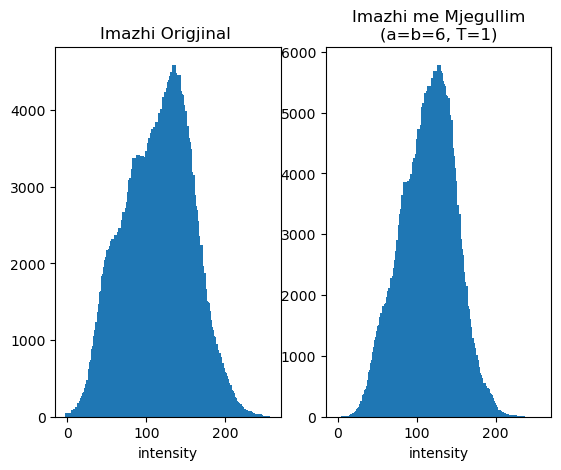

In [19]:
plot_hist(original_, blurred_, title_old="Imazhi Origjinal ", title_new="Imazhi me Mjegullim\n(a=b=6, T=1)")

### Filtri Weiner

Për të aplikuar Wiener filter mbi një imazh të turbulluar, mund të përdorësh funksionin `scipy.signal.wiener`

In [21]:
from scipy.signal import wiener

# Aplikimi i filterit Wiener
wiener_filtered = wiener(blurred)


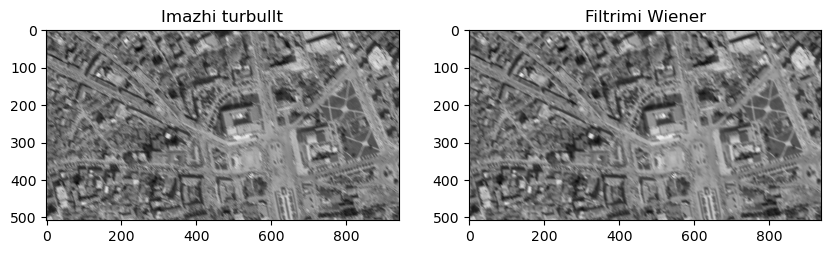

In [22]:
# Shfaqje e rezultateve

plot_image(blurred_, wiener_filtered, title_1="Imazhi turbullt", title_2="Filtrimi Wiener", gray = "yes")


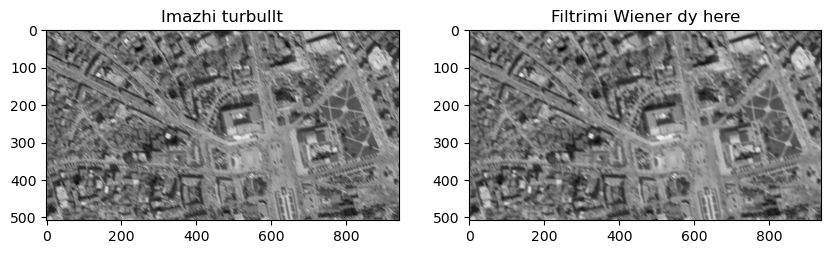

In [23]:
# Shfaqje e rezultateve
wiener_filtered2 = wiener(wiener_filtered)

plot_image(blurred_, wiener_filtered2, title_1="Imazhi turbullt", title_2="Filtrimi Wiener dy here", gray = "yes")


### Gabimin Mesatar Katror *(MSE - Mean Squared Error)*


Për të llogaritur **MSE** midis një imazhi origjinal `original_` dhe një imazhi të turbulluar `blurred_`, përdorim këtë formulë:

$$
\text{MSE} = \frac{1}{NM} \sum_{i=1}^{N}\sum_{j=1}^{M} (original[i][j] - blurred[i][j])^2
$$

Ku $N$ dhe $M$ është numri total i pikselëve.



In [25]:
# Supozojmë që original_ dhe blurred_ kanë të njëjtat dimensione
MSE = np.mean((original - blurred) ** 2)

print(f"Gabimi Mesatar Katror (MSE) është: {MSE}")



Gabimi Mesatar Katror (MSE) është: 0.016430727470174603



---


##### Rrenja e gabimit mesatar katror

$$
\text{RMSE} = \frac{\sum \left( \text{blurred_im}^2 \right)}{\left( \sum \left( \text{original_im} - \text{blurred_im} \right) \right)^2}
$$

In [26]:
RMSE = np.sum(blurred**2)/(np.sum(original - blurred) ** 2)

In [27]:
print(f"Rrënja e Gabimit Mesatar Katror (RMSE) është: {RMSE}")

Rrënja e Gabimit Mesatar Katror (RMSE) është: 128.3629409589086


### Filtri me gabim katror minimal të kufizuar (Constrained Least Squares Filter) -FGMK

FGMK përdoret për të rikuperuar një imazh të degraduar duke minimizuar gabimin katror mes imazhit të rikuperuar dhe atij origjinal, duke përfshirë një term rregullues për të kontrolluar amplifikimin e zhurmës gjatë deblurimit.

**Filtrimi me gabim katror minimal të kufizuar**

$$
F(u,v) = \left[ \frac{H^*(u,v)}{|H(u,v)|^2 + \gamma |P(u,v)|^2} \right] G(u,v)
$$
ku:

$P(u,v)$ është transformimi Fourier i funksionit

$$
p(x,y) = 
\begin{bmatrix}
0 & -1 & 0 \\
-1 & 4 & -1 \\
0 & -1 & 0
\end{bmatrix}
$$
dhe:

$\gamma$  është një parametër që kontrollon shkallën e rregullimit




In [67]:
import numpy as np
from numpy.fft import fft2, ifft2

def constrained_least_squares_filter(blurred, H, gamma=0.001):
    # Përmasat e imazhit
    M, N = blurred.shape

    # Filtri Laplacian 3x3 (në hapësirë)
    p = np.array([[0, -1, 0],
                  [-1, 4, -1],
                  [0, -1, 0]])

    # Krijimi i një matrice zero me të njëjtën madhësi si imazhi
    pad_p = np.zeros((M, N))
    
    # Vendosja e filtrit Laplacian në qendër të matrices
    cx, cy = M//2 - 1, N//2 - 1  # pozicioni për të vendosur p qendrorisht
    pad_p[cx:cx+3, cy:cy+3] = p

    # Transformimi Fourier i filtrit të rregullimit
    Puv = fft2(pad_p)

    # Transformimi Fourier i imazhit të turbulluar
    Guv = fft2(blurred)

    # Aplikimi i filtrit të Constrained Least Squares
    denominator = (np.abs(H)**2 + gamma * np.abs(Puv)**2)
    denominator[denominator == 0] = 1e-8  # për të shmangur ndarjen me zero

    Fuv = (np.conj(H) / denominator) * Guv

    # Rikthimi në domenin hapësinor
    f_hat = np.abs(ifft2(Fuv))

    return f_hat


Filtri turbullues H duhet të jetë i njëjtë me atë që është përdorur për ta turbulluar imazhin. Mund ta ndërtojme si më poshtë nëse është Gaussian:

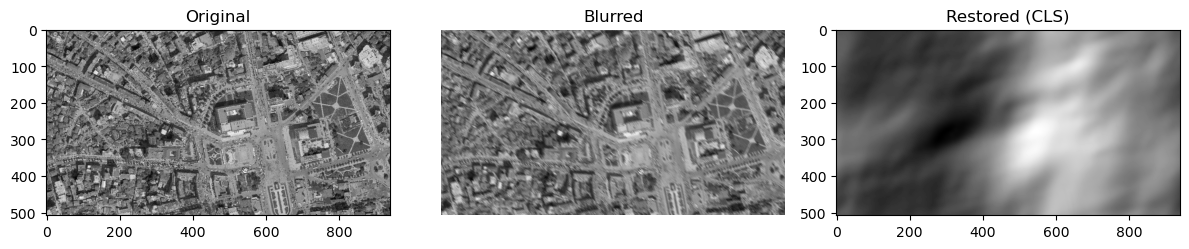

In [68]:
# Aplikojm filtrin
gamma = 5

restored = constrained_least_squares_filter(blurred_ , H_uv , gamma)

# Vizualizimi
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(original, cmap='gray')


plt.subplot(1, 3, 2)
plt.title("Blurred")
plt.imshow(blurred_, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Restored (CLS)")
plt.imshow(restored, cmap='gray')

plt.tight_layout()
plt.show()


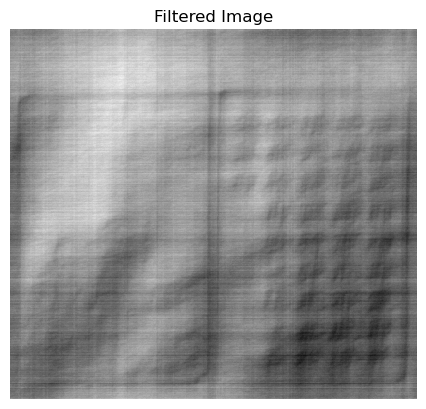

In [75]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Lexo imazhin dhe normalizo
original = cv2.imread('book.jpg', cv2.IMREAD_GRAYSCALE)
original = original.astype(np.float32) / 255.0

# Merr përmasat
M, N = original.shape
u = np.linspace(-0.5, 0.5, N)
v = np.linspace(-0.5, 0.5, M)
U, V = np.meshgrid(u, v)

# Parametra për motion blur
a, b = 6, 6  # drejtimi i turbullimit
T = 1           # koha e ekspozimit

# Gjenero funksionin e transferimit
H_uv = motion_blur_filter(U, V, a, b, T)

# FFT e imazhit dhe aplikimi i turbullimit
F = np.fft.fft2(original)
F_shifted = np.fft.fftshift(F)
G = F_shifted * H_uv

# Rikthehu në domenin hapësinor
blurred = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))
restored = constrained_least_squares_filter(blurred, H_uv, gamma=0.001)
plt.imshow(restored, cmap='gray')
plt.title("Filtered Image")
plt.axis('off')
plt.show()

In [71]:
from skimage import restoration

restored = restoration.richardson_lucy(blurred, psf=ifft2(H_uv), iterations=30)
plt.imshow(restored, cmap='gray')
plt.title("Filtered Image")
plt.axis('off')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_15540\2057208602.py:3: FutureWarning: `iterations` is a deprecated argument name for `richardson_lucy`. It will be removed in version 1.0. Please use `num_iter` instead.
  restored = restoration.richardson_lucy(blurred, psf=ifft2(H_uv), iterations=30)

KeyboardInterrupt



### Filtri mesatar gjeometrik

Filtri **mesatar gjeometrik** (geometric mean filter) është një **filter jo-linear** që përdoret shpesh për të reduktuar zhurmën **multiplikative** ose zhurmën speckle, dhe është efektiv kur dëshiron të ruash detajet në krahasim me filtrat linearë si filtrat mesatar apo gaussian.

---

Për një piksel në pozitën $(x, y)$, dhe një dritare $ m \times n $, vlera e filtruar llogaritet si:

$$
g(x, y) = \left( \prod_{(i,j) \in \text{dritarja}} f(x+i, y+j) \right)^{1/(m \cdot n)}
$$

Pra, merret **produkti i të gjitha pikselëve në dritare**, dhe më pas nxirret rrënja $m \cdot n$.

---



In [40]:
from scipy.ndimage import generic_filter

def geometric_mean_filter(image, kernel_size=3):
    def g_mean_filter_function(values):
        product = np.prod(values)
        return product ** (1.0 / len(values))
    
    return generic_filter(image, g_mean_filter_function, size=kernel_size)


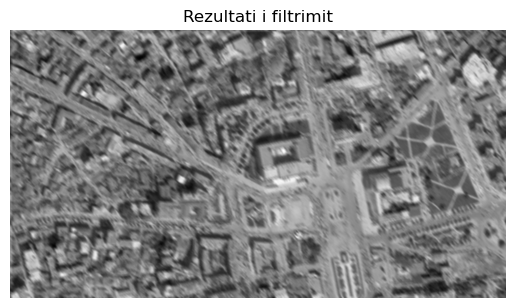

In [41]:

# Apliko mbi imazhin e turbulluar
geo_filtered = geometric_mean_filter(blurred, kernel_size=3)

# Vizualizim
plt.imshow(geo_filtered, cmap='gray')
plt.title("Rezultati i filtrimit")
plt.axis('off')
plt.show()

Permirsim i rezultatit te filtrimit

Ne mund ta përdorim bashkë me metoda të tjera (p.sh. pas filtrit Richardson-Lucy qe mermirson rezultatet ku gradienti ndryshone maksimalish:

In [44]:
deconvolved = restoration.richardson_lucy(blurred_, psf=H_uv, iterations=30)
geo_filtered = geometric_mean_filter(deconvolved, kernel_size=3)


C:\Users\User\AppData\Local\Temp\ipykernel_15540\4201177126.py:1: FutureWarning: `iterations` is a deprecated argument name for `richardson_lucy`. It will be removed in version 1.0. Please use `num_iter` instead.
  deconvolved = restoration.richardson_lucy(blurred_, psf=H_uv, iterations=30)
C:\Users\User\AppData\Local\Temp\ipykernel_15540\967100698.py:6: RuntimeWarning: invalid value encountered in scalar power
  return product ** (1.0 / len(values))


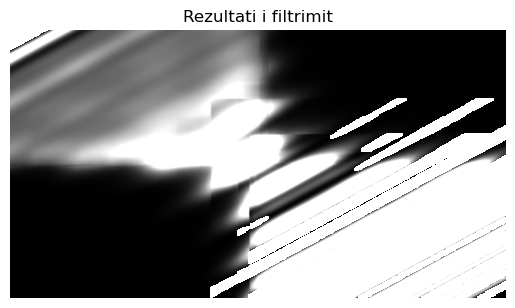

In [45]:
# Vizualizim
plt.imshow(geo_filtered, cmap='gray')
plt.title("Rezultati i filtrimit")
plt.axis('off')
plt.show()

# Referenca

[1]  Images were taken from: https://homepages.cae.wisc.edu/~ece533/images/
    
[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).

[5 ] Jian, Wushuai, Xueyan Sun, and Shuqian Luo. "Computer-aided diagnosis of breast microcalcifications based on dual-tree complex wavelet transform." Biomedical engineering online 11.1 (2012): 1-12.


<h3 align="center"> &#169; UMT. All rights reserved. <h3/>
    <h3 align="center"> anxheloshehu@umt.edu.al <h3/>